FLASH CALCULATION USING WILSON K-VALUES + RACHFORD-RICE
T = 341.00 K
P = 1700.00 kPa

Feed composition:
  Methane     z = 0.6100
  n-Butane    z = 0.2800
  n-Decane    z = 0.1100

Wilson K-values:
  Methane     K = 29.717955   (report value: 29.72)
  n-Butane    K = 0.455111   (report value: 0.46)
  n-Decane    K = 0.001867   (report value: 0.00)

beta_V min = -0.034821
beta_V max = 1.001870
beta_V root = 0.776293   (report value: 0.78)
Iterations = 21

Phase compositions:
Component          z_i           K_i           y_i           x_i
Methane         0.6100     29.717955      0.778239      0.026188
n-Butane        0.2800      0.455111      0.220849      0.485263
n-Decane        0.1100      0.001867      0.000912      0.488549

Rounded for report:
Component          z_i       K_i       y_i       x_i
Methane           0.61     29.72      0.78      0.03
n-Butane          0.28      0.46      0.22      0.49
n-Decane          0.11      0.00      0.00      0.49

Vapor amount  = 0.776293 mol

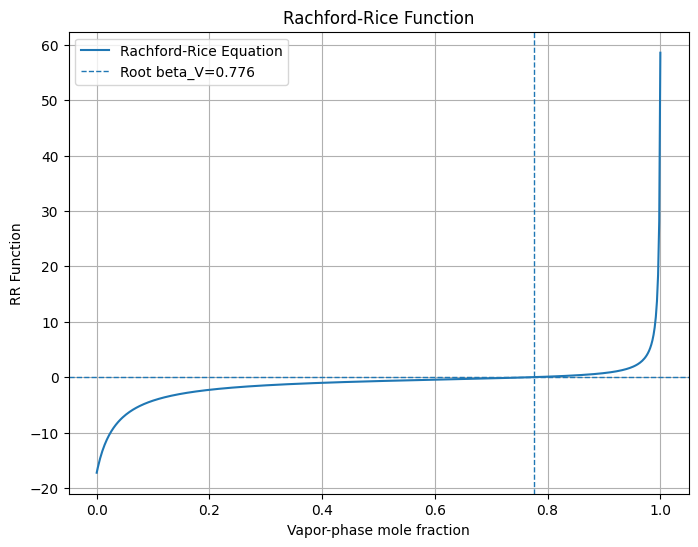

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# Part 1: Input data
# --------------------------------------------------

# System conditions
T = 341.0          # K
P = 1700.0         # kPa

# Feed composition z_i
# Order: Methane, n-Butane, n-Decane
components = ["Methane", "n-Butane", "n-Decane"]
z = np.array([0.61, 0.28, 0.11], dtype=float)

# Critical properties and acentric factors
# Tc in K, Pc in kPa, omega dimensionless
Tc = np.array([190.56, 425.12, 617.70], dtype=float)
Pc = np.array([4599.2, 3796.0, 2103.0], dtype=float)
omega = np.array([0.011, 0.200, 0.490], dtype=float)


# --------------------------------------------------
# Wilson correlation
# K_i = (Pc_i / P) * exp[5.373(1 + omega_i)(1 - Tc_i / T)]
# --------------------------------------------------
def wilson_K(T, P, Tc, Pc, omega):
    K = (Pc / P) * np.exp(5.373 * (1.0 + omega) * (1.0 - Tc / T))
    return K


# --------------------------------------------------
# Rachford-Rice function
# f(beta_V) = sum [ (1 - K_i) z_i / (1 - (1 - K_i) beta_V) ]
# This matches the pseudocode
# --------------------------------------------------
def rr_eval(beta_v, z, K):
    f = np.sum(((1.0 - K) * z) / (1.0 - (1.0 - K) * beta_v))
    return f


# --------------------------------------------------
# Solve for beta_v using bisection
# Bounds from pseudocode:
# beta_min = 1 / (1 - max(K))
# beta_max = 1 / (1 - min(K))
# --------------------------------------------------
def rachford_rice_bisection(z, K, tol=1e-6, max_iter=100):
    beta_min = 1.0 / (1.0 - np.max(K))
    beta_max = 1.0 / (1.0 - np.min(K))

    beta_l = beta_min
    beta_u = beta_max
    is_converged = False

    for iteration in range(1, max_iter + 1):
        beta_m = 0.5 * (beta_l + beta_u)
        f_m = rr_eval(beta_m, z, K)

        if abs(f_m) < tol:
            beta_root = beta_m
            is_converged = True
            break
        elif f_m > 0.0:
            beta_u = beta_m
        else:
            beta_l = beta_m

    if not is_converged:
        beta_root = beta_m
        print("Solution not found within max_iter; using final midpoint.")

    return beta_root, beta_min, beta_max, iteration


# --------------------------------------------------
# Phase compositions
# y_i = (K_i z_i) / (1 + beta_v (K_i - 1))
# x_i = y_i / K_i
# --------------------------------------------------
def phase_compositions(beta_v, z, K):
    y = (K * z) / (1.0 + beta_v * (K - 1.0))
    x = y / K
    return x, y


# --------------------------------------------------
# Main calculation
# --------------------------------------------------
K = wilson_K(T, P, Tc, Pc, omega)

beta_v, beta_min, beta_max, n_iter = rachford_rice_bisection(z, K)

x, y = phase_compositions(beta_v, z, K)

# Phase amounts for 1 mol feed
V = beta_v
L = 1.0 - beta_v

# Optional normalization check
sum_x = np.sum(x)
sum_y = np.sum(y)

# Rounded values for report-style output
K_round = np.round(K, 2)
x_round = np.round(x, 2)
y_round = np.round(y, 2)
beta_round = round(beta_v, 2)
V_round = round(V, 2)
L_round = round(L, 2)


# --------------------------------------------------
# Print results
# --------------------------------------------------
print("=" * 60)
print("FLASH CALCULATION USING WILSON K-VALUES + RACHFORD-RICE")
print("=" * 60)
print(f"T = {T:.2f} K")
print(f"P = {P:.2f} kPa")
print()

print("Feed composition:")
for i, comp in enumerate(components):
    print(f"  {comp:<10s}  z = {z[i]:.4f}")
print()

print("Wilson K-values:")
for i, comp in enumerate(components):
    print(f"  {comp:<10s}  K = {K[i]:.6f}   (report value: {K_round[i]:.2f})")
print()

print(f"beta_V min = {beta_min:.6f}")
print(f"beta_V max = {beta_max:.6f}")
print(f"beta_V root = {beta_v:.6f}   (report value: {beta_round:.2f})")
print(f"Iterations = {n_iter}")
print()

print("Phase compositions:")
print(f"{'Component':<12s}{'z_i':>10s}{'K_i':>14s}{'y_i':>14s}{'x_i':>14s}")
for i, comp in enumerate(components):
    print(f"{comp:<12s}{z[i]:>10.4f}{K[i]:>14.6f}{y[i]:>14.6f}{x[i]:>14.6f}")
print()

print("Rounded for report:")
print(f"{'Component':<12s}{'z_i':>10s}{'K_i':>10s}{'y_i':>10s}{'x_i':>10s}")
for i, comp in enumerate(components):
    print(f"{comp:<12s}{z[i]:>10.2f}{K_round[i]:>10.2f}{y_round[i]:>10.2f}{x_round[i]:>10.2f}")
print()

print(f"Vapor amount  = {V:.6f} mol   (report value: {V_round:.2f} mol)")
print(f"Liquid amount = {L:.6f} mol   (report value: {L_round:.2f} mol)")
print()

print(f"Check sum(x) = {sum_x:.6f}")
print(f"Check sum(y) = {sum_y:.6f}")
print("=" * 60)


# --------------------------------------------------
# Plot Rachford-Rice function
# --------------------------------------------------
beta_plot = np.linspace(0.0, 1.0, 500)
f_plot = []

for b in beta_plot:
    try:
        f_plot.append(rr_eval(b, z, K))
    except ZeroDivisionError:
        f_plot.append(np.nan)

f_plot = np.array(f_plot)

plt.figure(figsize=(8, 6))
plt.plot(beta_plot, f_plot, label="Rachford-Rice Equation")
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axvline(beta_v, linestyle="--", linewidth=1, label=f"Root beta_V={beta_v:.3f}")
plt.xlabel("Vapor-phase mole fraction")
plt.ylabel("RR Function")
plt.title("Rachford-Rice Function")
plt.legend()
plt.grid(True)
plt.show()